### Loading ad preping the data

In [46]:
import pandas as pd
import numpy as np
%pip install hdbscan

summary_df = pd.read_csv("summary_20260116.csv")
static_df = pd.read_csv("static_20260116.csv")
df = summary_df.merge(static_df, on = "RunID", how = "inner")
feature_cols = [
        # "max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        # "max_ram_used_mb",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]
assert len(df) == len(summary_df), "Different number of entries"
# print(df.head())
print(static_df["game_name"].value_counts(normalize=True))
print(static_df["training_type"].value_counts(normalize=True))
display(df[df["mean_cpu_usage_percent"] < 0][["RunID", "mean_cpu_usage_percent", "cpu"]])
display(df[["max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        "max_ram_used_mb",
        "mean_ram_used_mb"
        ]].corr())

Note: you may need to restart the kernel to use updated packages.
game_name
3DBall               0.434392
3DBallHard           0.278962
Crawler              0.103958
GridFoodCollector    0.051182
PushBlock            0.047122
FoodCollector        0.027548
Hallway              0.021314
Pyramids             0.007540
Walker               0.007540
Worm                 0.007540
Sorter               0.007105
GridWorld            0.005800
Name: proportion, dtype: float64
training_type
ppo    0.977671
sac    0.022329
Name: proportion, dtype: float64


,RunID,mean_cpu_usage_percent,cpu
5557,20260106-235341,-0.838145,AMD Ryzen 7 9800X3D 8-Core Processor
5559,20260107-000445,-0.829164,AMD Ryzen 7 9800X3D 8-Core Processor
5713,20260108-195651,-0.895181,AMD Ryzen 7 9800X3D 8-Core Processor
5716,20260108-201337,-0.142105,AMD Ryzen 7 9800X3D 8-Core Processor
5756,20260111-123319,-0.906045,Apple M2
5779,20260111-222828,-1.244013,Apple M2
5816,20260113-141804,-0.847948,Apple M2


,max_cpu_usage_percent,mean_cpu_usage_percent,max_ram_used_mb,mean_ram_used_mb
max_cpu_usage_percent,1.000000,0.928295,0.345947,0.353377
mean_cpu_usage_percent,0.928295,1.000000,0.530128,0.551596
max_ram_used_mb,0.345947,0.530128,1.000000,0.992663
mean_ram_used_mb,0.353377,0.551596,0.992663,1.000000


In [47]:
pd.crosstab(df["game_name"], df["training_type"])

training_type,ppo,sac
game_name,,
3DBall,2945,49
3DBallHard,1907,17
Crawler,689,28
GridFoodCollector,341,11
GridWorld,38,2
Hallway,138,9
PushBlock,317,8
Pyramids,44,8
Sorter,44,5


In [48]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

def get_subsample_mask(sanitized_df : pd.DataFrame, instances_per_machine_game_pair = 5):
    subsampled = sanitized_df.groupby(["cpu", "game_name", "training_type"], group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), instances_per_machine_game_pair),
            random_state=42
        )
    )
    used_run_ids = set(subsampled["RunID"])
    return sanitized_df["RunID"].isin(used_run_ids)

X = create_feature_data_frame(df)
display(df["time_per_1000_steps_sec"].describe())
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()
subsample_mask = get_subsample_mask(df_sanitized)

X_sanitized = X_sanitized[subsample_mask]
df_sanitized = df_sanitized[subsample_mask]

def get_sanitized_and_subsampled_features_and_org_df(df : pd.DataFrame, subsample = True, subsample_cap = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    if subsample:
        subsample_mask = get_subsample_mask(df_sanitized, instances_per_machine_game_pair=subsample_cap)
        X_sanitized = X_sanitized[subsample_mask].copy()
        df_sanitized = df_sanitized[subsample_mask].copy()
    return X_sanitized, df_sanitized

print(f"Number of significantly long runs (time_per_1000_stpes_sec > 10) : {len(X[X["time_per_1000_steps_sec"]>10])}")
print(f"Number of deleted entries : {len(X) - len(X_sanitized)}")
print(f"Number of entires remainig : {len(X_sanitized)}")

count    5878.000000
mean        1.548536
std        15.080312
min         0.021719
25%         0.345803
50%         0.430414
75%         0.624181
max       912.552125
Name: time_per_1000_steps_sec, dtype: float64

Number of significantly long runs (time_per_1000_stpes_sec > 10) : 110
Number of deleted entries : 6399
Number of entires remainig : 305


In [49]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_41203/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,15.000000,15.000000,15.000000
mean,21.901292,7738.551861,11.346332
std,7.099331,6889.900097,11.245968
min,9.701604,2904.025830,2.918337
25%,17.702841,2965.551459,4.159030
50%,20.930049,3591.258325,6.029525
75%,26.581125,13410.097384,16.097085
max,33.568833,19667.491211,39.201016


In [50]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    ax = plt.axes()
    ax.set_xscale("log")
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    plt.show()
    
# plot_distribuiton_of_features()


In [51]:
print(static_df.cpu.unique())
print(len(static_df[static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor"]))
# test = static_df[static_df["cpu"] == "Apple M1"]
# print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor") & (static_df["training_type"] == "sac")]
print(test["training_type"].value_counts())
print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "Apple M1") & (static_df["training_type"] == "sac")]
print(len(test))

['Apple M2' 'AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD'
 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD'
 'AMD Ryzen 7 5700X 8-Core Processor'
 'Intel64 Family 6 Model 154 Stepping 3, GenuineIntel'
 'AMD Ryzen 7 9800X3D 8-Core Processor' 'Apple M1']
4188
training_type
sac    12
Name: count, dtype: int64
game_name
Crawler              5
GridFoodCollector    1
Hallway              1
PushBlock            1
Pyramids             1
Sorter               1
Walker               1
Worm                 1
Name: count, dtype: int64
46


In [52]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_log = X_sanitized.copy()
    X_log["time_per_1000_steps_sec"] = np.log1p(X_log["time_per_1000_steps_sec"])
    # X_log["mean_ram_used_mb"] = np.log1p(X_log["mean_ram_used_mb"])
    X_scaled_as_array = scaler.fit_transform(X_log)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

def cluster(X_scaled_as_array : np.ndarray, n_init = "auto", n_clusters = 5) -> tuple[np.ndarray, KMeans]:
    clf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init, init="k-means++")
    clusters = clf.fit_predict(X_scaled_as_array)    
    return clusters, clf
    
def cluster_and_show(n_init = "auto", n_clusters = 5) -> None:
    X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
    X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
    X_scaled.describe()

    X_scaled["clusters"] = cluster(X_scaled_as_array, n_init=n_init, n_clusters = n_clusters)[0]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = X_scaled["clusters"])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
def show_clustered(X_scaled) -> None:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    clusters = X_scaled["cluster"].unique()

    for cluster in clusters:
        mask = X_scaled["cluster"] == cluster
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f"Cluster {cluster}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Clusters")
    plt.show()

In [53]:
import numpy as np

def show_clustered_3d_log(X_with_clusters) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    clusters = X_with_clusters["cluster"].unique()

    for cluster in clusters:
        mask = X_with_clusters["cluster"] == cluster
        ax.scatter(
            X_with_clusters.loc[mask, "mean_cpu_usage_percent"],
            X_with_clusters.loc[mask, "mean_ram_used_mb"],
            X_with_clusters.loc[mask, "time_per_1000_steps_sec"],
            label=f"Cluster {cluster}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="Clusters")
    plt.show()


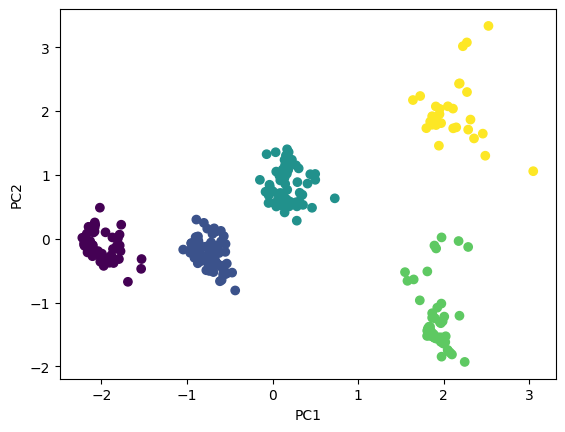

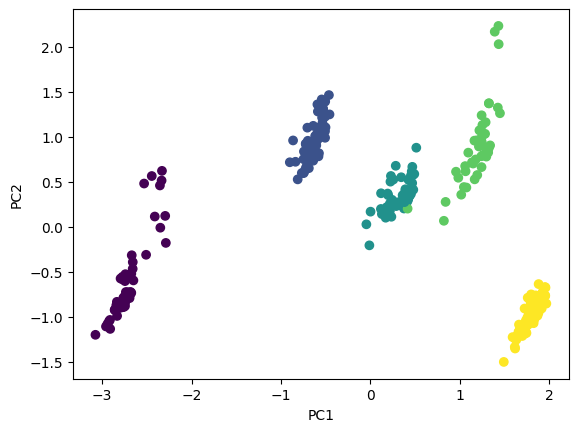

In [54]:
cluster_and_show(n_init="auto")
cluster_and_show(n_init=10)



In [55]:
import numpy as np
pca = PCA(n_components=2)
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
X_pca_1 = pca.fit_transform(X_scaled)
X_pca_2 = pca.fit_transform(X_scaled)

np.allclose(X_pca_1, X_pca_2)

labels_auto = KMeans(n_clusters=5, n_init="auto", random_state=42).fit_predict(X_scaled)
labels_10 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

(labels_auto == labels_10).mean()


0.02622950819672131

In [56]:
clusters, clf = cluster(X_scaled_as_array)
X_sanitized["cluster"] = clf.labels_
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# print(cluster_summary)
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = X_sanitized["cluster"]
# static_cluster_3 = df_sanitized.loc[X_sanitized["cluster"] == 3]
# print(static_cluster_3)
# static_cluster_3.head()
# X_sanitized[X_sanitized["cluster"] == 3]["RunID"]
# X_sanitized
# print(summary_df_sanitized[X_sanitized["cluster"] == 3])
# df_sanitized[X_sanitized["cluster"] == 3]
# df_sanitized_with_clusters.head()
print(df_sanitized_with_clusters.columns)
print(X_sanitized["cluster"].value_counts())

Index(['RunID', 'final_reward', 'max_reward', 'time_to_max_reward_sec',
       'total_duration_sec', 'mean_policy_loss', 'mean_value_loss',
       'mean_entropy', 'final_entropy', 'max_cpu_usage_percent',
       'mean_cpu_usage_percent', 'max_ram_used_mb', 'mean_ram_used_mb',
       'mean_cpu_frequency', 'max_cpu_frequency', 'max_gpu_usage_percent',
       'mean_gpu_usage_percent', 'max_vram_used_mb', 'mean_vram_used_mb',
       'max_game_cpu_usage_percent', 'mean_game_cpu_usage_percent',
       'max_game_memory_usage_mb', 'mean_game_memory_usage_mb', 'id', 'os',
       'cpu', 'physical_cores', 'system_ram_gb', 'gpu', 'GPU_ram_mb',
       'cuda_version', 'training_type', 'game_name', 'batch_size',
       'learning_rate', 'buffer_size', 'beta', 'epsilon', 'lambd', 'num_epoch',
       'learning_rate_schedule', 'normalize', 'hidden_units', 'num_layers',
       'vis_encode_type', 'reward_extrinsic_gamma',
       'reward_extrinsic_strength', 'keep_checkpoints', 'max_steps',
       'time_hor

In [57]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"])

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,11,5,7,5,5,5,5,6,5,5,5
1,12,5,10,5,0,9,10,10,5,9,10
2,9,7,10,7,1,5,4,5,4,6,6
3,10,6,6,6,0,6,6,6,5,6,6
4,3,2,3,6,3,3,2,0,6,1,0


In [58]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
cluster,,
0,60,4
1,79,6
2,12,52
3,56,7
4,5,24


In [59]:
pd.crosstab(df_sanitized_with_clusters["game_name"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
game_name,,
3DBall,30,15
3DBallHard,15,10
Crawler,20,16
GridFoodCollector,20,9
GridWorld,7,2
Hallway,20,8
PushBlock,20,7
Pyramids,20,7
Sorter,20,5


In [60]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["cpu"])

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,59,0,5,0,0,0
1,0,0,0,0,38,47
2,12,0,0,0,40,12
3,0,57,0,5,0,1
4,13,1,0,0,7,8


In [61]:
display(cluster_summary)
display(df_sanitized_with_clusters)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                     6.692370   4.815721   1.737500  23.240663   
1                    28.101192   5.119424  18.182631  42.872490   
2                    22.417554   6.140109   5.927114  41.572500   
3                    65.109619   5.752359  47.310843  79.356251   
4                    22.173112  11.330652   4.636000  55.329807   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0           13397.266893  4123.569696  8366.276391  23669.109756   
1            3435.551358   286.994028  2698.507463   3886.866675   
2            5001.183972  4044.979905  2588.723328  18610.375195   
3           21799.849899  3078.768584  4220.743938  26883.274096   
4            9329.969535  6689.107754  2716.735413  19947.100000   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
0                      1.246317    0.964768   0.349650    4.849650  
1                      1.755820    1.022348   0.627457    4.802352  
2                     11.320870    6.411206   3.805167   25.862674  
3                      2.061752    4.567693   0.021719   23.334980  
4                    104.949583  182.015414  19.792436  912.552125

,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq,time_per_1000_steps_sec,cluster
29,20251123-040931,10.214287,10.214287,127.226204,127.226204,0.033689,0.559972,1.416729,1.414638,10.400000,...,2,simple,NaN,NaN,5,250000,512,12000,0.508905,0
31,20251123-042835,3.445076,3.692000,254.029999,258.188232,0.017186,0.191176,1.401258,1.375831,5.950000,...,3,simple,NaN,NaN,5,500000,2048,12000,0.516376,0
81,20251123-104448,1.660690,1.725176,129.753540,152.015106,0.024820,0.082402,1.410354,1.398661,6.166667,...,3,simple,NaN,NaN,5,250000,2048,12000,0.608060,0
118,20251123-153643,100.000008,100.000008,246.015533,676.480347,0.017768,0.018413,1.233955,1.118035,12.100000,...,2,simple,NaN,NaN,5,1000000,64,12000,0.676480,0
122,20251123-013820,100.000015,100.000015,35498.843750,35765.726560,0.035430,0.164357,1.359259,1.319901,63.799999,...,2,simple,NaN,NaN,5,1000000,256,12000,35.765727,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,20260116-060309,-0.999979,-0.993875,162.688583,705.916443,0.017407,0.002717,1.485066,1.437377,27.700001,...,2,simple,NaN,NaN,5,500000,128,12000,1.411833,1
6700,20260116-100352,-0.999600,-0.628293,2973.324219,6930.989746,0.017469,0.009543,3.217676,3.133424,30.566668,...,2,simple,NaN,NaN,5,1000000,64,12000,6.930990,2
6701,20260116-120952,-0.654694,-0.634638,1017.768127,1224.885864,0.012455,0.148526,1.421677,1.427139,39.200001,...,2,simple,NaN,NaN,5,500000,256,12000,2.449772,1
6702,20260116-093955,-1.208650,-0.984809,1354.183228,1392.265381,0.017453,0.007896,3.291550,3.282615,30.025000,...,2,simple,NaN,NaN,5,250000,2048,12000,5.569062,2


In [62]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

Q1 = X_sanitized.quantile(0.25)
Q3 = X_sanitized.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_sanitized < (Q1 - 1.5 * IQR)) | (X_sanitized > (Q3 + 1.5 * IQR))
outlier_rows = outlier_mask.any(axis=1)
len(outlier_rows == False)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
print(df_sanitized["game_name"].value_counts(normalize=True))
print(df_sanitized["training_type"].value_counts(normalize=True))

game_name
3DBall               0.147541
Crawler              0.118033
GridFoodCollector    0.095082
Hallway              0.091803
PushBlock            0.088525
Walker               0.088525
Pyramids             0.088525
Worm                 0.088525
Sorter               0.081967
3DBallHard           0.081967
GridWorld            0.029508
Name: proportion, dtype: float64
training_type
ppo    0.695082
sac    0.304918
Name: proportion, dtype: float64


In [99]:
from sklearn.metrics import silhouette_score
# For finding proper k
def silhouette_scores_search(X_scaled_as_array):
    k_range = range(2, 20)

    inertias = []
    silhouette_scores = []


    for k in k_range:
        # kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
        kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
        labels = kmeans.fit_predict(X_scaled_as_array)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
        
    results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

    print(results)
    
silhouette_scores_search(X_scaled_as_array)

     k     inertia  silhouette_score
0    2  276.151215          0.569267
1    3  159.300060          0.508127
2    4  100.245088          0.542144
3    5   82.792655          0.511137
4    6   69.868794          0.515445
5    7   56.883250          0.519449
6    8   50.996142          0.498517
7    9   47.646358          0.449129
8   10   44.332161          0.408138
9   11   34.128960          0.435321
10  12   31.820020          0.429943
11  13   30.065445          0.421711
12  14   26.677030          0.414516
13  15   25.198494          0.421238
14  16   23.748627          0.412313
15  17   23.009035          0.411111
16  18   22.346386          0.396534
17  19   20.943576          0.395165


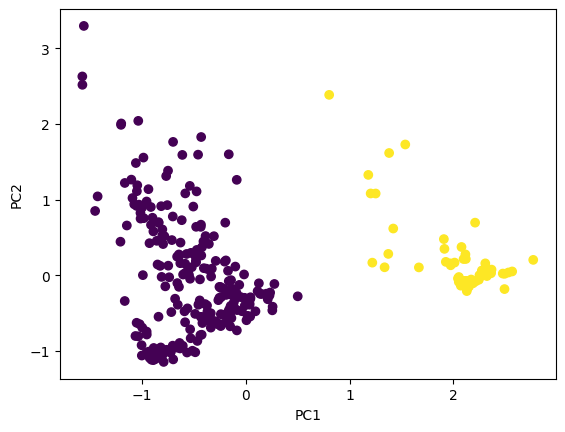

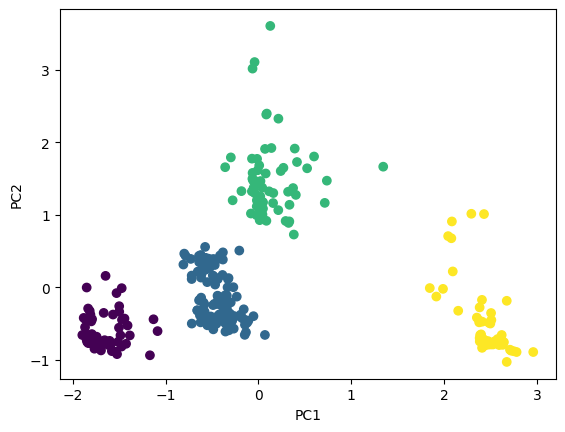

In [64]:
cluster_and_show(n_clusters=2)
cluster_and_show(n_clusters=4)

mean_cpu_usage_percent                                  \
                          mean       std        min        max   
cluster                                                          
0                     6.847818  4.837469   1.737500  23.240663   
1                    26.897032  5.247939  16.153333  42.872490   
2                    22.044082  9.372026   4.636000  55.329807   
3                    65.109619  5.752359  47.310843  79.356251   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0           13316.046479  4092.856959  8366.276391  23669.109756   
1            3519.757044  1408.262860  2588.723328  18110.803320   
2            7549.015877  5967.670966  2660.485742  19947.100000   
3           21799.849899  3078.768584  4220.743938  26883.274096   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
0                      1.387674    1.248726  0.349650    6.418514  
1                      2.954839    2.301853  0.627457   10.115502  
2                     59.378913  133.082428  9.671429  912.552125  
3                      2.061752    4.567693  0.021719   23.334980

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,12,6,7,5,5,5,5,6,5,5,5
1,17,9,14,10,1,9,11,12,9,11,13
2,6,4,9,8,3,8,5,3,6,5,3
3,10,6,6,6,0,6,6,6,5,6,6


training_type,ppo,sac
cluster,,
0,60,6
1,89,27
2,7,53
3,56,7


cpu           AMD Ryzen 7 5700X 8-Core Processor      \
training_type                                ppo sac   
cluster                                                
0                                             55   6   
1                                              0   1   
2                                              0  22   
3                                              0   0   

cpu           AMD Ryzen 7 9800X3D 8-Core Processor      \
training_type                                  ppo sac   
cluster                                                  
0                                                0   0   
1                                                0   0   
2                                                0   1   
3                                               50   7   

cpu           AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD  \
training_type                                               ppo   
cluster                                                           
0                                                             5   
1                                                             0   
2                                                             0   
3                                                             0   

cpu           AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD Apple M1      \
training_type                                               ppo      ppo sac   
cluster                                                                        
0                                                             0        0   0   
1                                                             0       45  14   
2                                                             0        0  26   
3                                                             5        0   0   

cpu           Apple M2      
training_type      ppo sac  
cluster                     
0                    0   0  
1                   44  12  
2                    7   4  
3                    1   0

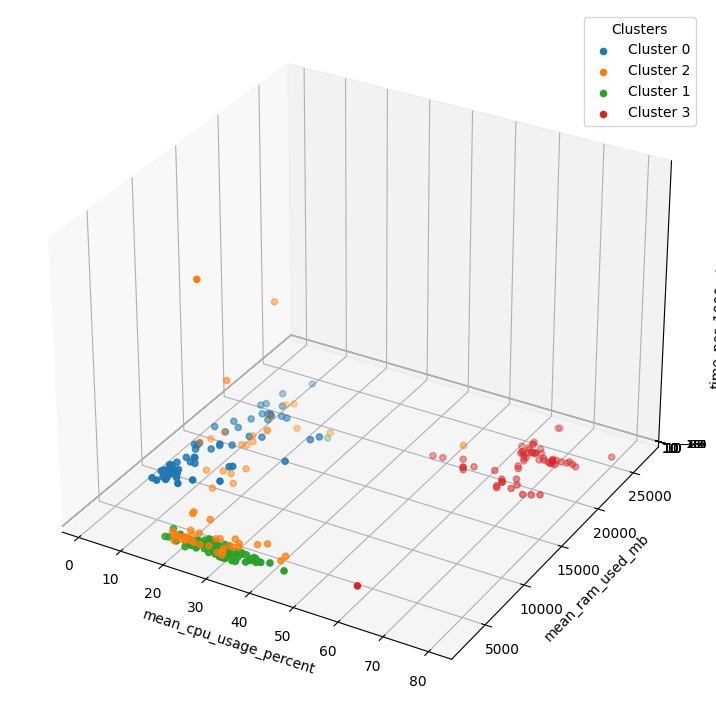

In [65]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=4, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
display(cluster_summary)
pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"], [df_sanitized_with_clusters[col] for col in ["cpu","training_type"]]))
show_clustered_3d_log(X_sanitized)


In [66]:
X_sanitized.corr()
X_sanitized["cluster"].value_counts()

cluster
1    116
0     66
3     63
2     60
Name: count, dtype: int64

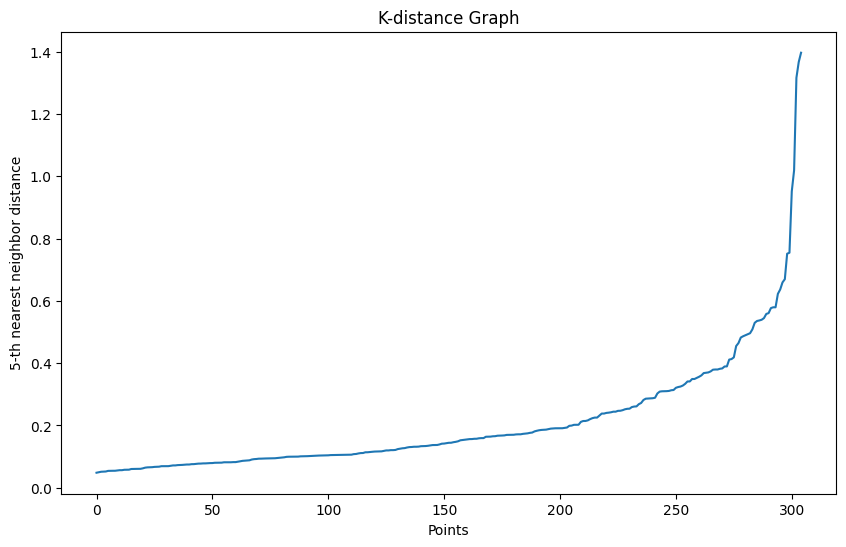

In [67]:
X_sanitized_dbscan, df_sanitized_dbscan = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled_dbscan, X_scaled_as_array_dbscan = get_scaled_df_and_np(X_sanitized_dbscan)

from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X_scaled_dbscan)
    distances, _ = neigh.kneighbors(X_scaled_dbscan)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [68]:
from sklearn.cluster import DBSCAN

def get_noise_from_eps_range(X_scaled_as_array_dbscan, eps_start, eps_end, eps_interval = 0.1) -> dict:
    noise_dict = {}
    eps_curr = eps_start
    while(eps_curr <= eps_end):            
        dbscan = DBSCAN(eps = eps_curr, min_samples = 5)
        labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
        noise_dict[eps_curr] = np.sum(labels == -1)/len(labels)
        eps_curr+=eps_interval
    return noise_dict

for k, v in get_noise_from_eps_range(X_scaled_as_array_dbscan, 0.2, 0.8).items():
    print(f"Epsilon = {k}, noise = {v}")

Epsilon = 0.2, noise = 0.25573770491803277
Epsilon = 0.30000000000000004, noise = 0.1540983606557377
Epsilon = 0.4, noise = 0.07868852459016394
Epsilon = 0.5, noise = 0.04590163934426229
Epsilon = 0.6, noise = 0.01639344262295082
Epsilon = 0.7, noise = 0.01639344262295082
Epsilon = 0.7999999999999999, noise = 0.013114754098360656


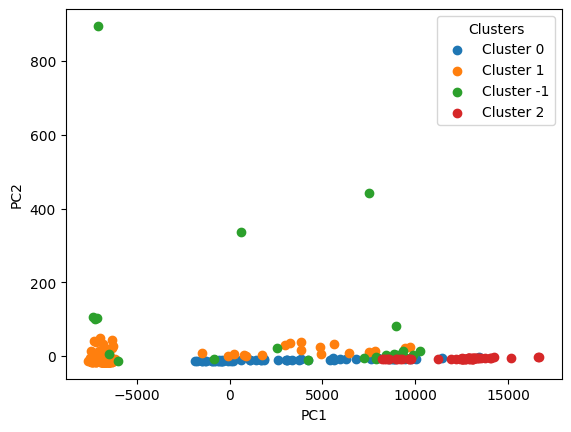

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   36.760734  20.181750   4.636000  73.460501   
 0                    6.046012   3.483534   1.737500  14.512500   
 1                   25.238453   6.733655   5.927114  42.872490   
 2                   66.205697   4.617537  49.398394  79.356251   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          13859.445186  6832.078205   2823.696663  20464.625000   
 0          13218.494180  4112.457024   8366.276391  23669.109756   
 1           4535.657434  3583.367230   2588.723328  19947.100000   
 2          22461.584827  1999.277855  18424.992647  26883.274096   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                    97.387953  206.855983  0.708888  912.552125  
 0                     1.276027    1.079918  0.349650    5.403695  
 1                    10.146317   13.732722  0.627457   64.998672  
 2                     0.674185    0.528937  0.021719    2.659151

cluster
 1    165
 0     62
 2     54
-1     24
Name: count, dtype: int64

In [69]:
dbscan = DBSCAN(eps = 0.4)
labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
X_sanitized_dbscan["cluster"] = labels
df_sanitized_dbscan["cluster"] = labels
show_clustered(X_sanitized_dbscan)

cluster_dbscan_summary = (
    X_sanitized_dbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_dbscan_summary)
X_sanitized_dbscan["cluster"].value_counts()

In [70]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["game_name"]))

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,9,8,0,1,4,2
0,57,0,5,0,0,0
1,18,0,0,0,81,66
2,0,50,0,4,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,5,1,1,3,1,3,2,1,5,1,1
0,10,6,7,4,5,5,4,6,5,5,5
1,21,13,23,17,3,15,16,15,10,16,16
2,9,5,5,5,0,5,5,5,5,5,5


In [71]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan[df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor"]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["os"]))
display(pd.crosstab(df_sanitized_dbscan["cpu"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab( df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,4,0,0,1,1,1,1,0,1,0,0
0,5,6,7,4,5,5,4,6,5,5,5
1,1,4,3,5,1,1,1,0,0,1,1


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cluster,,,,,
-1,4,5,4,2,9
0,44,18,0,0,0
1,18,0,81,66,0
2,0,0,0,0,54


os,Windows 11,macOS
cluster,,
-1,18,6
0,62,0
1,18,147
2,54,0


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cpu,,,,,
AMD Ryzen 7 5700X 8-Core Processor,66,18,0,0,0
AMD Ryzen 7 9800X3D 8-Core Processor,0,0,0,0,58
"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",0,5,0,0,0
"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",0,0,0,0,5
Apple M1,0,0,85,0,0
Apple M2,0,0,0,68,0


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,9,8,0,1,4,2
0,57,0,5,0,0,0
1,18,0,0,0,81,66
2,0,50,0,4,0,0


In [72]:
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "Apple M2")]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor")]["game_name"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,2,5,5,5,5,5,5
sac,5,5,5,1,0,0,0,0,0,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,5,5,5,5,5,5,5
sac,5,5,5,5,2,2,1,1,1,1,1


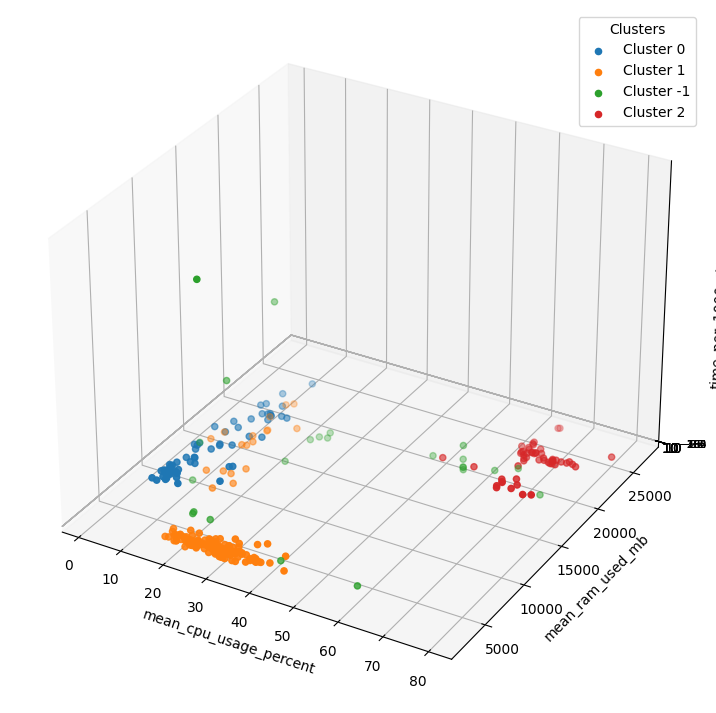

In [73]:

show_clustered_3d_log(X_sanitized_dbscan)

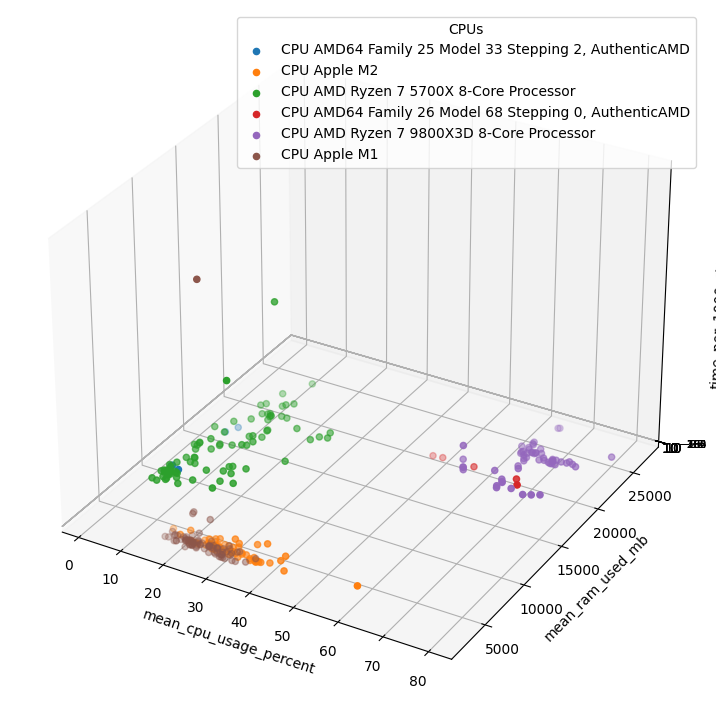

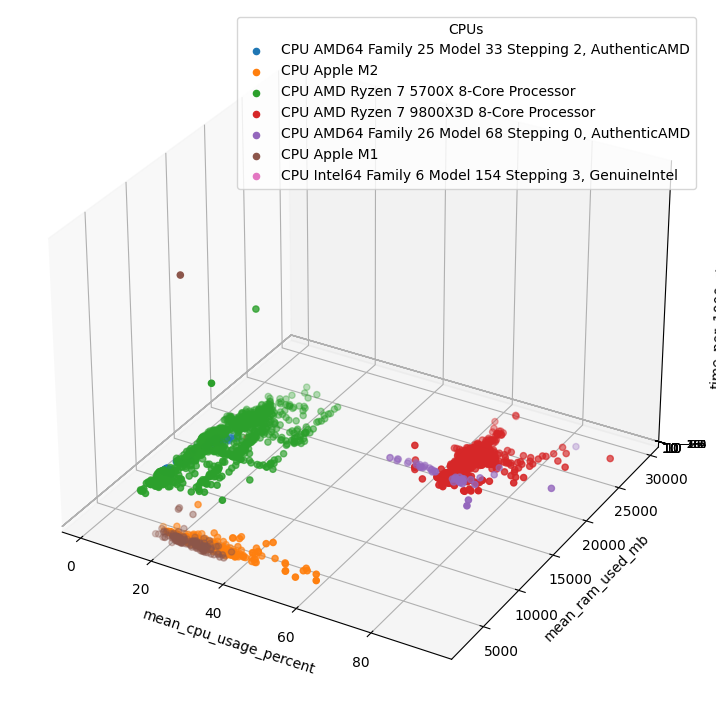

In [74]:
def show_by_cpu_3d_log(X) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    cpus = X["cpu"].unique()

    for cpu in cpus:
        mask = X["cpu"] == cpu
        ax.scatter(
            X.loc[mask, "mean_cpu_usage_percent"],
            X.loc[mask, "mean_ram_used_mb"],
            X.loc[mask, "time_per_1000_steps_sec"],
            label=f"CPU {cpu}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="CPUs")
    plt.show()

show_by_cpu_3d_log(df_sanitized_dbscan)
show_by_cpu_3d_log(df)

In [75]:
display(static_df[["cpu", "system_ram_gb"]].drop_duplicates())
display(static_df[["gpu", "system_ram_gb"]].drop_duplicates())

,cpu,system_ram_gb
0,Apple M2,8589930000
10,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",34265700000
203,"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",66157800000
208,AMD Ryzen 7 5700X 8-Core Processor,34265700000
253,"Intel64 Family 6 Model 154 Stepping 3, Genuine...",34027700000
433,AMD Ryzen 7 9800X3D 8-Core Processor,66157800000
1161,Apple M1,8589930000


,gpu,system_ram_gb
0,Chipset Model: Apple M2,8589930000
10,NVIDIA GeForce RTX 5080,34265700000
203,NVIDIA GeForce RTX 5070 Ti,66157800000
253,NVIDIA GeForce RTX 3080 Ti Laptop GPU,34027700000
1161,Chipset Model: Apple M1,8589930000


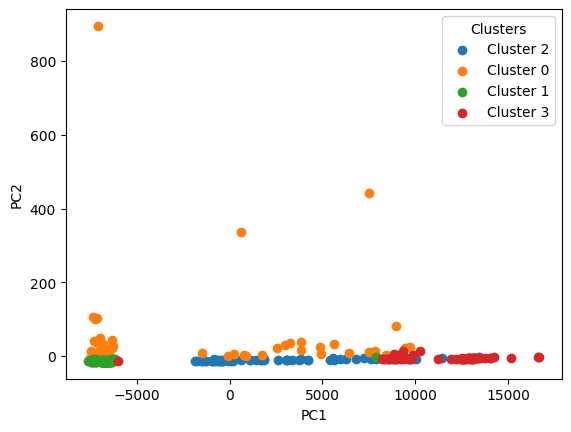

mean_cpu_usage_percent                                  \
                          mean       std        min        max   
cluster                                                          
0                    22.044082  9.372026   4.636000  55.329807   
1                    26.897032  5.247939  16.153333  42.872490   
2                     6.847818  4.837469   1.737500  23.240663   
3                    65.109619  5.752359  47.310843  79.356251   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0            7549.015877  5967.670966  2660.485742  19947.100000   
1            3519.757044  1408.262860  2588.723328  18110.803320   
2           13316.046479  4092.856959  8366.276391  23669.109756   
3           21799.849899  3078.768584  4220.743938  26883.274096   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
0                     59.378913  133.082428  9.671429  912.552125  
1                      2.954839    2.301853  0.627457   10.115502  
2                      1.387674    1.248726  0.349650    6.418514  
3                      2.061752    4.567693  0.021719   23.334980

cluster
1    116
2     66
3     63
0     60
Name: count, dtype: int64


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,22,1,0,0,26,11
1,1,0,0,0,59,56
2,61,0,5,0,0,0
3,0,57,0,5,0,1


cpu           AMD Ryzen 7 5700X 8-Core Processor      \
training_type                                ppo sac   
cluster                                                
0                                              0  22   
1                                              0   1   
2                                             55   6   
3                                              0   0   

cpu           AMD Ryzen 7 9800X3D 8-Core Processor      \
training_type                                  ppo sac   
cluster                                                  
0                                                0   1   
1                                                0   0   
2                                                0   0   
3                                               50   7   

cpu           AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD  \
training_type                                               ppo   
cluster                                                           
0                                                             0   
1                                                             0   
2                                                             5   
3                                                             0   

cpu           AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD Apple M1      \
training_type                                               ppo      ppo sac   
cluster                                                                        
0                                                             0        0  26   
1                                                             0       45  14   
2                                                             0        0   0   
3                                                             5        0   0   

cpu           Apple M2      
training_type      ppo sac  
cluster                     
0                    7   4  
1                   44  12  
2                    0   0  
3                    1   0

,cluster,cpu,mean_ram_used_mb,mean_cpu_usage_percent,time_per_1000_steps_sec
214,2,AMD Ryzen 7 5700X 8-Core Processor,13275.275097,2.225000,0.568606
220,2,AMD Ryzen 7 5700X 8-Core Processor,17009.433398,4.439167,0.490881
271,2,AMD Ryzen 7 5700X 8-Core Processor,17820.676699,7.110241,0.967071
337,2,AMD Ryzen 7 5700X 8-Core Processor,15816.170850,2.115417,0.647903
413,2,AMD Ryzen 7 5700X 8-Core Processor,19653.250000,5.890625,0.822630
...,...,...,...,...,...
5701,0,AMD Ryzen 7 5700X 8-Core Processor,14067.400879,14.936750,47.936266
5705,2,AMD Ryzen 7 5700X 8-Core Processor,12042.533447,13.137500,1.188433
5706,2,AMD Ryzen 7 5700X 8-Core Processor,15771.006680,10.655750,4.849650
5707,0,AMD Ryzen 7 5700X 8-Core Processor,18024.936719,11.307667,23.079779


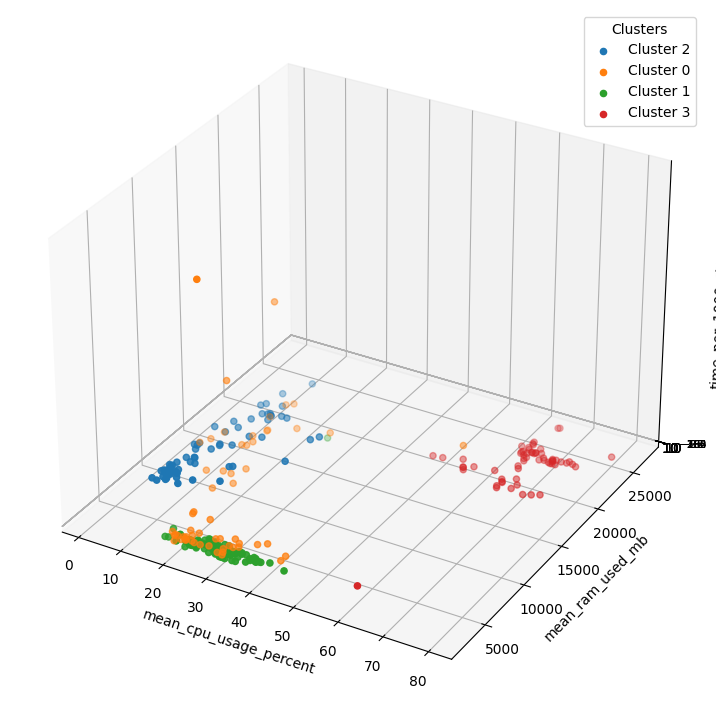

In [ ]:
import hdbscan
X_sanitized_hdbscan, df_sanitized_hdbscan = get_sanitized_and_subsampled_features_and_org_df(df, subsample=True, subsample_cap=5)
X_scaled_hdbscan, X_scaled_as_array_hdbscan = get_scaled_df_and_np(X_sanitized_hdbscan)

hdbscan_clf = hdbscan.HDBSCAN(min_cluster_size=5, min_samples= 3, cluster_selection_epsilon=0.4)
hdbscan_clf.fit(X_scaled_as_array_hdbscan)
X_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
df_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
show_clustered(X_sanitized_hdbscan)

cluster_hdbscan_summary = (
    X_sanitized_hdbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_hdbscan_summary)
print(X_sanitized_hdbscan["cluster"].value_counts())
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["cpu"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], [df_sanitized_hdbscan[col] for col in ["cpu","training_type"]]))
display(df_sanitized_hdbscan[df_sanitized_hdbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor"][["cluster", "cpu", "mean_ram_used_mb", "mean_cpu_usage_percent", "time_per_1000_steps_sec"]])
show_clustered_3d_log(X_sanitized_hdbscan)
print(hdbscan_clf.cluster_persistence_)

In [77]:
summ_test_df = pd.read_csv("summary_20260116.csv")
stat_test_df = pd.read_csv("static_20260116.csv")
print(len(summ_test_df))
print(len(stat_test_df))
print(stat_test_df[~stat_test_df["RunID"].isin(summ_test_df["RunID"])]["cpu"].unique())


6704
6897
['Intel64 Family 6 Model 154 Stepping 3, GenuineIntel' 'Apple M2']


/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_41203/4230666366.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)


     k    inertia  silhouette_score
0    2  79.293399          0.321922
1    3  58.997829          0.344403
2    4  49.032991          0.318121
3    5  36.859769          0.314517
4    6  28.832582          0.317262
5    7  26.596568          0.290542
6    8  25.125453          0.280995
7    9  24.184080          0.249447
8   10  20.667547          0.278561
9   11  17.534707          0.311660
10  12  16.312078          0.322641
11  13  14.313931          0.326140
12  14  13.149008          0.336935
13  15  12.522658          0.326434
14  16  11.672217          0.326325
15  17  10.722267          0.321767
16  18  10.116834          0.326768
17  19   9.275853          0.335156


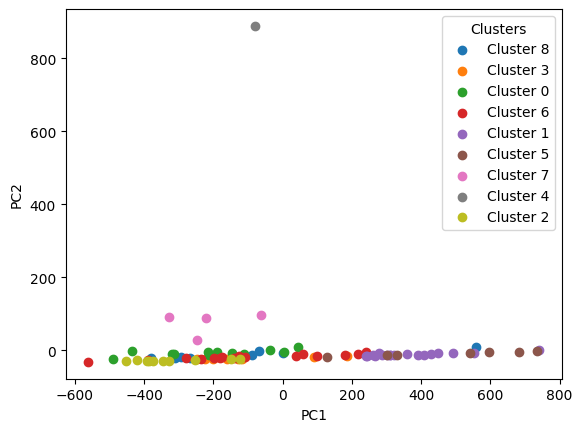

mean_cpu_usage_percent                                  \
                          mean       std        min        max   
cluster                                                          
0                    20.522419  2.093855  17.622333  24.670000   
1                    24.726815  2.094133  20.941936  27.527555   
2                    29.582614  1.895735  26.835000  32.836044   
3                    20.143069  2.131870  16.166667  22.350000   
4                    24.949333       NaN  24.949333  24.949333   
5                    31.374992  2.150174  29.502083  35.838095   
6                    21.857601  1.864218  16.961932  25.391045   
7                    24.335994  1.880877  22.844810  26.976000   
8                    29.743843  2.522785  26.077500  35.183750   

        mean_ram_used_mb                                        \
                    mean         std          min          max   
cluster                                                          
0            2949.045562  166.909627  2660.485742  3195.872919   
1            3519.476820  128.956905  3391.063254  3891.660828   
2            2827.456288  111.761620  2698.507463  3026.452381   
3            3050.126883  155.612192  2904.025830  3335.119048   
4            3093.520010         NaN  3093.520010  3093.520010   
5            3623.939108  224.244343  3278.845808  3886.866675   
6            3051.139021  216.794877  2588.723328  3391.046670   
7            2937.776128  111.235665  2823.696663  3089.586169   
8            3044.985704  300.540999  2769.441176  3708.500000   

        time_per_1000_steps_sec                                     
                           mean        std         min         max  
cluster                                                             
0                     20.882318   6.237138   10.674992   31.498943  
1                      2.267704   1.828983    0.627457    7.147681  
2                      2.619967   1.545550    1.148856    5.954784  
3                      2.424583   1.426665    1.212303    4.883506  
4                    912.552125        NaN  912.552125  912.552125  
5                      1.669960   0.538958    1.012892    2.322791  
6                      6.736923   2.152141    4.257222   11.606421  
7                    103.869319  31.224121   57.159785  122.156383  
8                     13.067853   4.898118    7.255198   22.893842

cluster
1    18
6    17
0    12
2    10
8     8
3     8
5     7
7     4
4     1
Name: count, dtype: int64


cpu,Apple M1
cluster,
0,12
1,18
2,10
3,8
4,1
5,7
6,17
7,4
8,8


training_type,ppo,sac
cluster,,
0,0,12
1,16,2
2,9,1
3,5,3
4,0,1
5,7,0
6,8,9
7,0,4
8,0,8


game_name,3DBall,Crawler,GridFoodCollector,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,
0,0.1,0.2,0.000000,0.4,0.3,0.0,0.000,0.2,0.0
1,0.5,0.3,0.000000,0.1,0.4,0.1,0.125,0.2,0.1
2,0.0,0.3,0.142857,0.0,0.0,0.1,0.000,0.2,0.3
3,0.3,0.0,0.000000,0.4,0.1,0.0,0.000,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.125,0.0,0.0
5,0.0,0.0,0.000000,0.0,0.0,0.3,0.000,0.1,0.3
6,0.1,0.2,0.571429,0.1,0.2,0.0,0.500,0.2,0.1
7,0.0,0.0,0.285714,0.0,0.0,0.0,0.250,0.0,0.0
8,0.0,0.0,0.000000,0.0,0.0,0.5,0.000,0.1,0.2


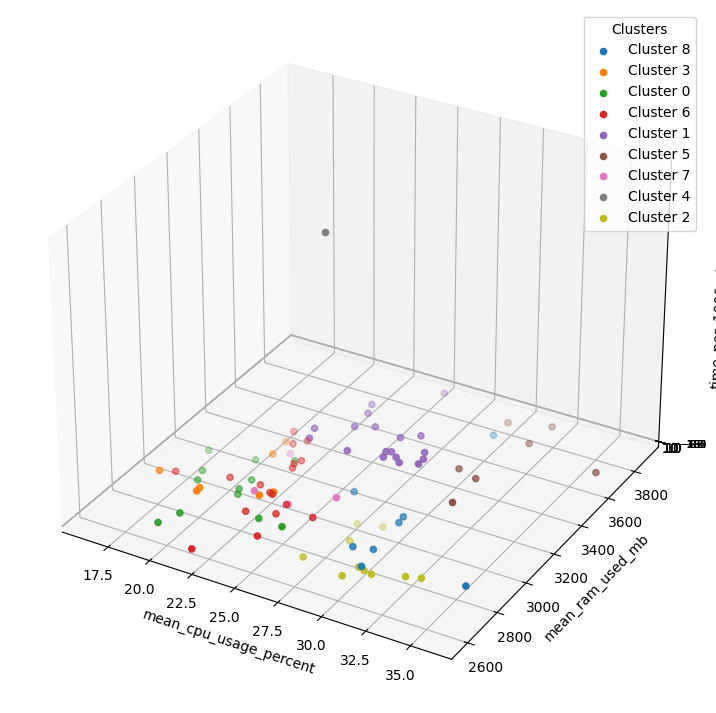

In [100]:
mine_sanitized_hdbscan, df_sanitized_hdbscan = get_sanitized_and_subsampled_features_and_org_df(df[df["cpu"] == "Apple M1"], subsample=True, subsample_cap=5)
mine_scaled_hdbscan, mine_scaled_as_array_hdbscan = get_scaled_df_and_np(mine_sanitized_hdbscan)

silhouette_scores_search(mine_scaled_as_array_hdbscan)

# hdbscan_clf = hdbscan.HDBSCAN(min_cluster_size=5)
hdbscan_clf = KMeans(n_clusters=9)
hdbscan_clf.fit(mine_scaled_as_array_hdbscan)
mine_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
df_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
show_clustered(mine_sanitized_hdbscan)

cluster_hdbscan_summary = (
    mine_sanitized_hdbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_hdbscan_summary)
print(mine_sanitized_hdbscan["cluster"].value_counts())
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["cpu"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["training_type"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["game_name"], normalize='columns'))
show_clustered_3d_log(mine_sanitized_hdbscan)